# Proyecto Final DataXperience

## Análisis y predicción de la rotación de empleados mediante ciencia de datos

**Objetivo:** Analizar qué características están relacionadas con la rotación de empleados y qué tan bien podemos predecir si un empleado abandonará la empresa.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## 1. Análisis Exploratorio de Datos (EDA)

Se realiza un análisis exploratorio para comprender la estructura del conjunto de datos, verificar la calidad de la información y conocer el comportamiento de las variables antes de construir los modelos predictivos.

In [2]:
df = pd.read_csv("Empleados_Renuncias.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [4]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [29]:
variables = [
    'satisfaction_level',
    'average_montly_hours',
    'number_project',
    'time_spend_company'
]

estadisticas = pd.DataFrame({
    'Media': df[variables].mean(),
    'Mediana': df[variables].median(),
    'Moda': df[variables].mode().iloc[0],
    'Rango': df[variables].max() - df[variables].min(),
    'Varianza': df[variables].var(),
    'Desviación estándar': df[variables].std()
})

estadisticas

,Media,Mediana,Moda,Rango,Varianza,Desviación estándar
satisfaction_level,0.629658,0.66,0.74,0.91,0.058115,0.241070
average_montly_hours,200.473522,200.00,149.00,214.00,2374.399778,48.727813
number_project,3.802852,4.00,4.00,5.00,1.353123,1.163238
time_spend_company,3.364857,3.00,3.00,8.00,1.769537,1.330240


In [6]:
df.duplicated().sum()

np.int64(3008)

In [7]:
print("Registros antes de eliminar duplicados:", len(df))

df = df.drop_duplicates()

print("Registros después de eliminar duplicados:", len(df))
print("Duplicados restantes:", df.duplicated().sum())

Registros antes de eliminar duplicados: 14999
Registros después de eliminar duplicados: 11991
Duplicados restantes: 0


In [8]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

* *NOTA:* No hay nulos (dataset limpio)

In [9]:
df['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

In [10]:
print("\nDistribución de empleados que se van (left):")
print(df['left'].value_counts(normalize=True))


Distribución de empleados que se van (left):
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


## 2. Visualización de los datos

En esta sección se generan diferentes visualizaciones con el objetivo de identificar patrones, tendencias y relaciones entre las variables que puedan explicar la rotación de empleados.

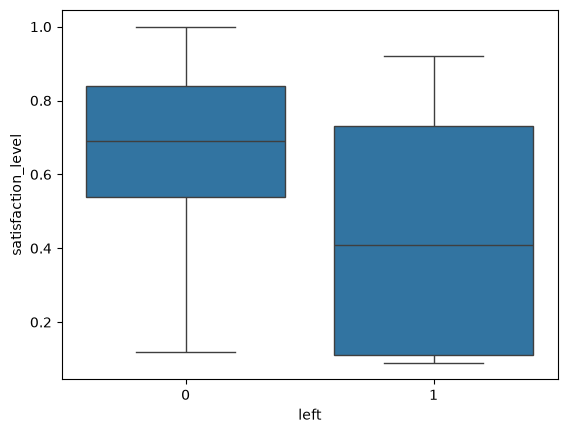

In [12]:
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.show()

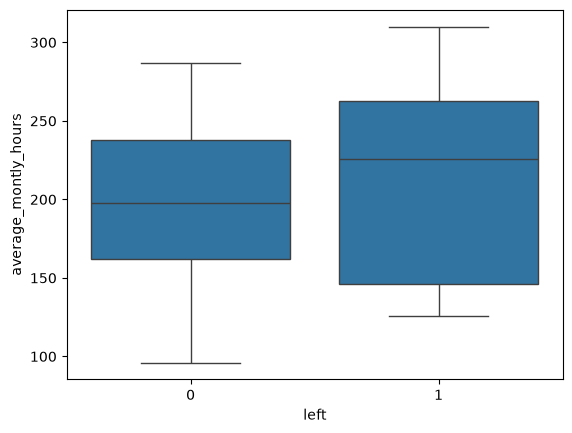

In [13]:
sns.boxplot(x='left', y='average_montly_hours', data=df)
plt.show()

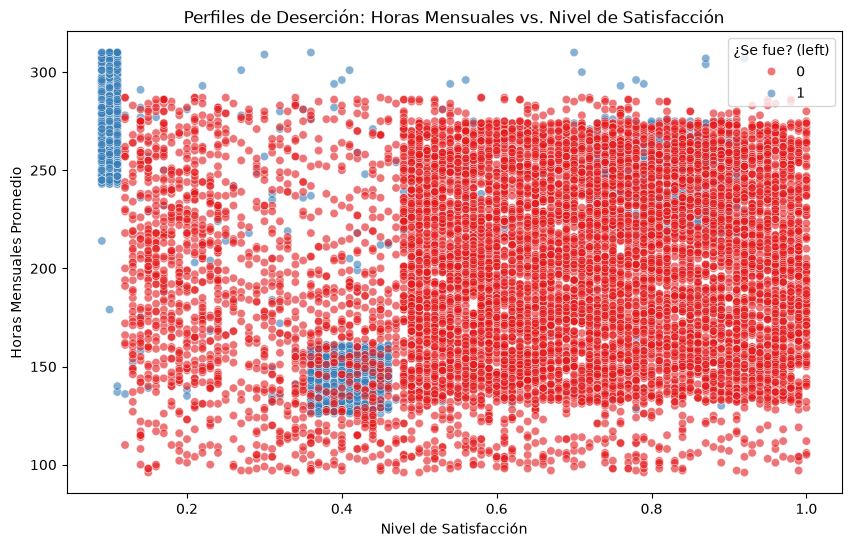

In [14]:
plt.figure(figsize=(10, 6))
#Este grafico de dispersion segmentara a los empleados
sns.scatterplot(data=df, x='satisfaction_level', y='average_montly_hours', hue='left', alpha=0.6, palette='Set1')
plt.title('Perfiles de Deserción: Horas Mensuales vs. Nivel de Satisfacción')
plt.xlabel('Nivel de Satisfacción')
plt.ylabel('Horas Mensuales Promedio')
plt.legend(title='¿Se fue? (left)')
plt.show()

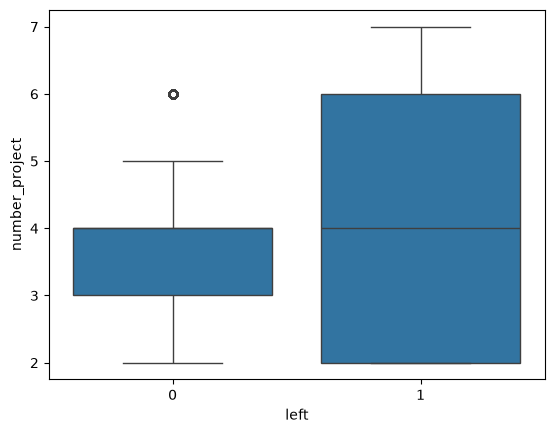

In [15]:
sns.boxplot(x='left', y='number_project', data=df)
plt.show()

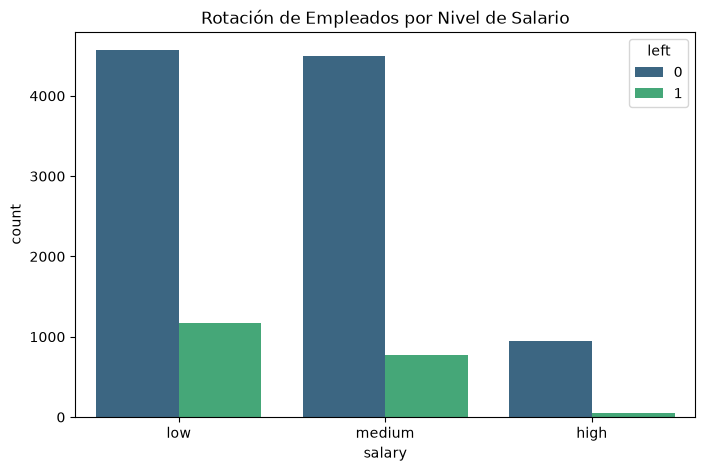

In [16]:
# Impacto del salario en la rotación
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='salary', hue='left', palette='viridis')
plt.title('Rotación de Empleados por Nivel de Salario')
plt.show()

## 3.Creación del modelos

### 1. Preparación de los datos

Para el entrenamiento de los modelos fue necesario transformar las variables categóricas mediante One-Hot Encoding (`get_dummies`), permitiendo que los algoritmos de Machine Learning puedan procesarlas correctamente.

In [17]:
df = pd.get_dummies(
    df,
    columns=['Department', 'salary'],
    drop_first=True
)

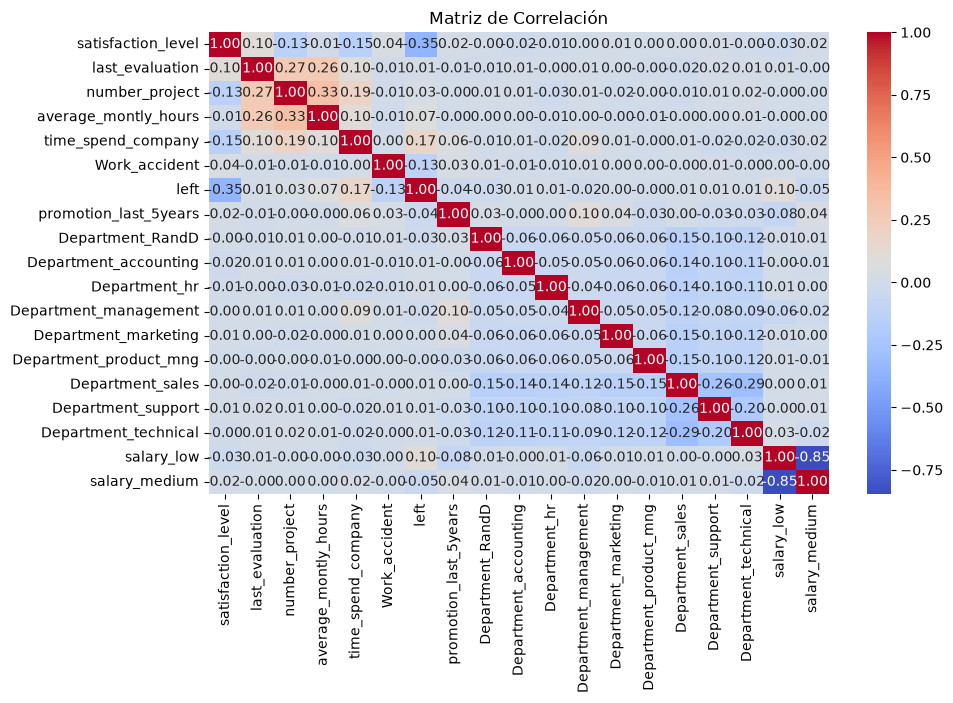

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [19]:
print(df.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department_RandD', 'Department_accounting',
       'Department_hr', 'Department_management', 'Department_marketing',
       'Department_product_mng', 'Department_sales', 'Department_support',
       'Department_technical', 'salary_low', 'salary_medium'],
      dtype='str')


### 2. División del conjunto de datos

El conjunto de datos se dividió en entrenamiento (80%) y prueba (20%) utilizando `train_test_split`, conservando la proporción de la variable objetivo mediante `stratify`.

In [20]:
from sklearn.model_selection import train_test_split

# Separar las X de y
# X tendra todo (satisfacción, horas, salario...) excepto la columna 'left'
X = df.drop(columns=['left']) 

# y solo tendrá la columna 'left' (0 si se quedo, 1 si se fue)
y = df['left'] 

# Hacer la division matemática
# asegurar que en ambos grupos haya el mismo porcentaje de gente que se fue.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Datos para que el modelo estudie (Train): {X_train.shape[0]} empleados")
print(f"Datos para hacerle el examen al modelo (Test): {X_test.shape[0]} empleados")

Datos para que el modelo estudie (Train): 9592 empleados
Datos para hacerle el examen al modelo (Test): 2399 empleados


### Metodología para la selección del modelo

Para abordar el problema de predicción de la rotación de empleados, se siguió una metodología de aprendizaje supervisado para clasificación binaria, donde la variable objetivo fue left, que indica si un empleado abandonó (1) o permaneció (0) en la empresa.

### Se entrenaron dos modelos de clasificación:

* **Regresión Logística**, utilizada como modelo base por su simplicidad e interpretabilidad.
* **Random Forest**, seleccionado por su capacidad para modelar relaciones no lineales, manejar múltiples variables y estimar la importancia de cada característica.

La selección del modelo se realizó comparando las métricas obtenidas sobre el conjunto de prueba, específicamente:

* **Accuracy**
* **Precision**
* **Recall**
* **F1-Score**

### Modelo 1 - Regresión Logística

Se utiliza la Regresión Logística como modelo base para establecer un punto de comparación frente a otros algoritmos de clasificación.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Escalar los datos para probar la Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar el modelo de Regresión Logística
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
print("¡Regresión logistica entrenado con éxito!\n")

# Prueba final con los datos de prueba escalados
predicciones_log = log_reg.predict(X_test_scaled)

print(" REPORTE DE RENDIMIENTO EN EL EXAMEN (TEST) ")
print(classification_report(y_test, predicciones_log))

¡Regresión logistica entrenado con éxito!

 REPORTE DE RENDIMIENTO EN EL EXAMEN (TEST) 
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.50      0.21      0.30       398

    accuracy                           0.83      2399
   macro avg       0.68      0.59      0.60      2399
weighted avg       0.80      0.83      0.81      2399



### Modelo 2 - Random Forest

Se implementa Random Forest debido a su capacidad para capturar relaciones no lineales entre variables y proporcionar información sobre la importancia de cada característica.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Crear modelo Random Forest con una profundidad maxima de 12 para evitar sobreajuste
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)

# entrenar modelo con los datos originales
rf_model.fit(X_train, y_train)
print("¡Random forest entrenado con éxito!\n")

# Prueba final con los datos de prueba 
predicciones_rf = rf_model.predict(X_test)

print(" REPORTE DE RENDIMIENTO EN EL EXAMEN (TEST) ")
print(classification_report(y_test, predicciones_rf))

¡Random forest entrenado con éxito!

 REPORTE DE RENDIMIENTO EN EL EXAMEN (TEST) 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.95       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



## 4. Comparativa de Modelos

### Comparativa de Resultados

Para comparar el rendimiento de los modelos se utilizaron las métricas de precisión (Precision), sensibilidad (Recall) y F1-Score sobre el conjunto de prueba. La clase 1 representa a los empleados que abandonaron la empresa.

**Regresión Logística (F1-Score clase 1 = 0.30):**
La Regresión Logística presentó un rendimiento menor para identificar a los empleados que abandonaron la empresa. Aunque obtuvo una precisión del 83% en el conjunto de prueba, su Recall para la clase 1 fue de 0.21, lo que significa que identificó correctamente aproximadamente el 21% de los casos reales de abandono. Esto indica que, para este conjunto de datos, el modelo lineal tiene dificultades para capturar las relaciones más complejas entre las diferentes variables.

**Random Forest (F1-Score clase 1 = 0.95):**
Random Forest obtuvo un mejor desempeño en la identificación de la clase 1. Alcanzó una precisión de 0.99, un Recall de 0.92 y un F1-Score de 0.95 para los empleados que abandonaron la empresa. Esto significa que el modelo identificó correctamente el 92% de los casos reales de abandono presentes en el conjunto de prueba y que el 99% de las predicciones de abandono realizadas por el modelo correspondieron a casos que efectivamente pertenecían a esta clase.

En comparación con la Regresión Logística, Random Forest logró capturar mejor las relaciones no lineales y las combinaciones entre las variables utilizadas en el análisis.

### Diagnóstico de Sobreajuste (Overfitting)

Para evaluar un posible sobreajuste se comparó el rendimiento del modelo Random Forest sobre los datos de entrenamiento y los datos de prueba.

* **Entrenamiento (Train):** F1-Score clase 1 = 0.98
* **Prueba (Test):** F1-Score clase 1 = 0.95

La diferencia entre ambos resultados es relativamente pequeña, por lo que **no se observa una evidencia marcada de sobreajuste en esta evaluación**. El parámetro `max_depth=12` también limita la profundidad de los árboles y ayuda a controlar la complejidad del modelo.

Sin embargo, estos resultados no garantizan por sí solos que el modelo tenga el mismo desempeño con datos reales o futuros. Sería necesario realizar validaciones adicionales con nuevos conjuntos de datos para comprobar su capacidad de generalización.

### Modelo Propuesto

Para este proyecto se propone **Random Forest Classifier**, debido a que presentó un mejor desempeño que la Regresión Logística en la identificación de empleados pertenecientes a la clase 1. Además, permite analizar la importancia relativa de las variables utilizadas por el modelo, lo que facilita la interpretación de los factores que más contribuyen a sus predicciones.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)


rf_model.fit(X_train, y_train)
print("¡Modelo entrenado con éxito en esta celda!\n")

predicciones_test = rf_model.predict(X_test)


print("REPORTE DE RENDIMIENTO EN EL EXAMEN (TEST)")
print(classification_report(y_test, predicciones_test))


print("REPORTE DE RENDIMIENTO EN EL ENTRENAMIENTO (TRAIN)")
predicciones_train = rf_model.predict(X_train)
print(classification_report(y_train, predicciones_train))

¡Modelo entrenado con éxito en esta celda!

REPORTE DE RENDIMIENTO EN EL EXAMEN (TEST)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.95       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399

REPORTE DE RENDIMIENTO EN EL ENTRENAMIENTO (TRAIN)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7999
           1       0.99      0.94      0.96      1593

    accuracy                           0.99      9592
   macro avg       0.99      0.97      0.98      9592
weighted avg       0.99      0.99      0.99      9592



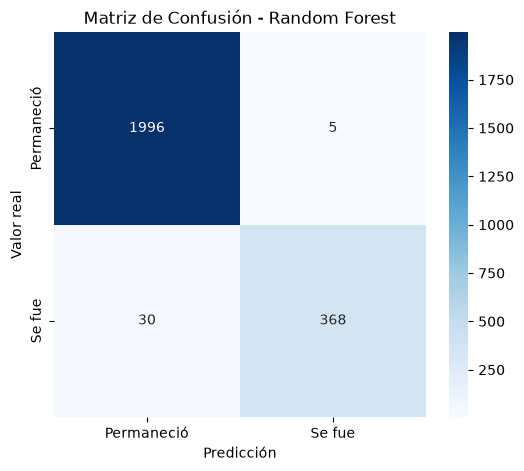

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicciones_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Permaneció', 'Se fue'],
    yticklabels=['Permaneció', 'Se fue']
)

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

In [26]:
print("Train:", rf_model.score(X_train,y_train))
print("Test:", rf_model.score(X_test,y_test))

Train: 0.9885321100917431
Test: 0.9854105877448937


* *NOTA:*
El rendimiento del modelo en entrenamiento y prueba es similar, por lo que no se observa evidencia significativa de sobreajuste.

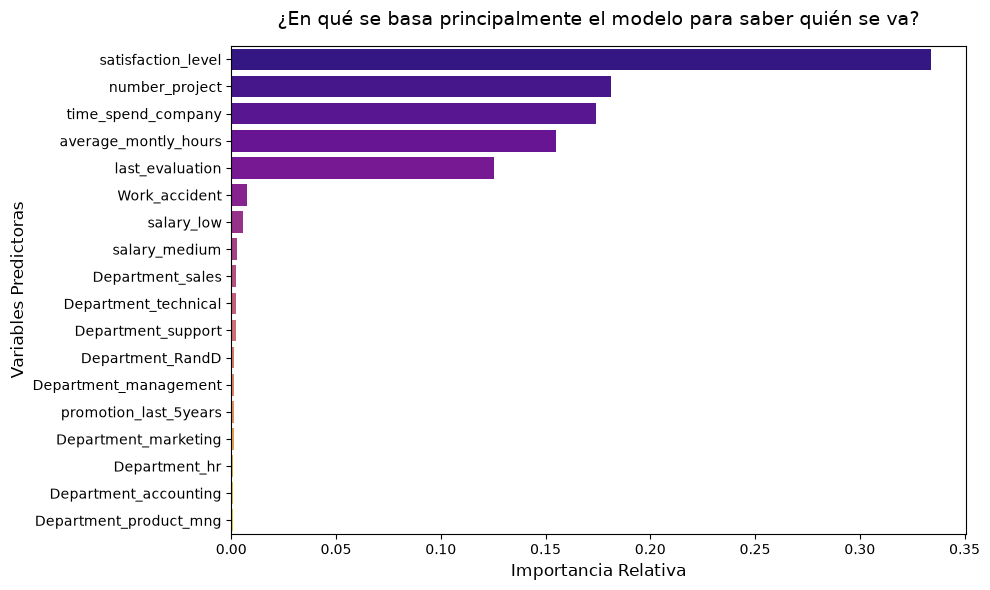

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Se extrae que tanto pesa cada variable segun el modelo
importancias = rf_model.feature_importances_

#Ordenar las columnas de mayor a menor importancia
indices = np.argsort(importancias)[::-1]

#Tamaño
plt.figure(figsize=(10, 6))

# Grafico de barras
sns.barplot(
    x=importancias[indices],
    y=X.columns[indices],
    hue=X.columns[indices], 
    palette='plasma',
    legend=False
)

# 5. Agregamos el título principal y las etiquetas de los ejes
plt.title('¿En qué se basa principalmente el modelo para saber quién se va?', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)

# 6. Ajustamos el diseño y mostramos la gráfica limpia
plt.tight_layout()
plt.show()

### Conclusiones de Importancia de Variables (Feature Importance)

El análisis de importancia del modelo **Random Forest** demuestra que la decisión de deserción de un empleado no es aleatoria y está fuertemente centralizada en **5 factores clave**:

1. **satisfaction_level:** Es el predictor principal. Un bajo nivel de satisfacción laboral es el detonante definitivo para que un empleado decida marcharse.
2. **number_project y average_montly_hours:** Estas dos métricas reflejan un problema de sobrecarga laboral. Los extremos disparan el riesgo de fuga.
3. **time_spend_company:** El modelo detecta una zona de peligro crítica en la antigüedad del empleado, específicamente entre los **3 y los 5 años** dentro de la empresa.
4. **last_evaluation:** Afecta tanto por bajo rendimiento como por alto rendimiento.

**Hallazgo Estratégico:** Es de gran relevancia para el negocio observar que tanto el **Salario** como los **Departamentos** se ubican en la parte inferior de la gráfica con un peso cercano a cero. Esto demuestra que el problema de rotación **no está ligado a un área en específico ni a una insatisfacción puramente salarial**, sino a un problema de **clima laboral Y balance de cargas**.

# 5. Conclusiones y Aplicación Profesional

## Conclusiones

A partir del análisis realizado sobre la rotación de empleados, fue posible identificar diferentes características relacionadas con el abandono de la empresa y evaluar la capacidad de distintos modelos de Machine Learning para realizar esta predicción.

Durante la preparación de los datos se identificaron **3.008 registros duplicados**, los cuales fueron eliminados. El conjunto de datos pasó de **14.999 a 11.991 registros**, sin registros duplicados restantes y sin valores nulos.

El análisis exploratorio permitió observar diferencias entre los empleados que permanecieron en la empresa y aquellos que la abandonaron, especialmente en variables como el **nivel de satisfacción, número de proyectos, horas mensuales trabajadas y antigüedad**.

Para la etapa predictiva se compararon dos modelos. La **Regresión Logística** obtuvo un Accuracy de **83%** y un F1-Score de **0.30 para la clase 1**, mostrando dificultades para identificar correctamente los casos de abandono. Por otro lado, **Random Forest** obtuvo un Accuracy de aproximadamente **99%**, con un Recall de **0.92** y un F1-Score de **0.95 para la clase 1**.

Estos resultados muestran que, para este conjunto de datos, Random Forest logró capturar mejor las relaciones y combinaciones entre las variables utilizadas. Además, la comparación entre los resultados de entrenamiento y prueba no mostró evidencia marcada de sobreajuste en esta evaluación.

El análisis de importancia de variables permitió identificar que **satisfaction_level, number_project, average_montly_hours y time_spend_company** tuvieron una participación importante en las predicciones del modelo. Sin embargo, estos resultados representan asociaciones predictivas y no permiten afirmar que estas variables sean causas directas de la rotación.

## Aplicación Profesional

Este análisis podría utilizarse como punto de partida para desarrollar una herramienta de **analítica de Recursos Humanos**. Por ejemplo, una empresa podría integrar información histórica de sus empleados para identificar patrones relacionados con la rotación y generar indicadores que permitan realizar un seguimiento de variables como satisfacción, carga laboral, proyectos y antigüedad.

Los resultados también podrían integrarse posteriormente en un **dashboard de Power BI**, permitiendo visualizar indicadores de rotación y segmentarlos por diferentes características de los empleados.

De esta manera, la ciencia de datos puede complementar el análisis tradicional de Recursos Humanos proporcionando información que facilite la identificación de patrones y apoye la toma de decisiones basada en datos.